In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
import seaborn as sns
import re, math
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import ConnectionPatch
from matplotlib.ticker import MultipleLocator, FormatStrFormatter
from pathlib import Path
from brokenaxes import brokenaxes

# 获取当前路径
ROOT = '/root/workspace/vllm-dynamic/scripts'
DATASET_PATH=f'{ROOT}/dataset/e2e'
PDF_PATH=f'{ROOT}/pdf'
line_styles = ['-', '--', '-.', ':', 'solid', 'dashed', 'dashdot', 'dotted', '-', '--', '-.', ':', 'solid', 'dashed', 'dashdot', 'dotted']
markers = ['o', 's', 'D', '^', 'v', 'x', '+', '1', '2', '3', '4', '8', 'p', '*', 'h', 'H', '<', '>', 'd']
hatches = hatches = ['...', '--', '///', '\\\\\\', '+', 'x', 'o', 'O', '.', '*', '0', '1', '2', '3', '4', '5', '6', '7', '8']

In [123]:
def get_data_from_log(model_name, system_names, dataset_paths, output_csv_path):
    # Define metrics to collect
    metrics = {
        'output_throughput': [],
        'mean_ttft': [],
        'p99_ttft': [],
        'mean_tpot': [],
        'p99_tpot': [],
        'mean_itl': [],
        'p99_itl': []
    }
    
    # Compile regex pattern once (fixed syntax error in original)
    pattern = re.compile(
        r"Output token throughput \(tok/s\):\s+(?P<output_throughput>\d+\.\d+).*?"
        r"Mean TTFT \(ms\):\s+(?P<mean_ttft>\d+\.\d+).*?"
        r"P99 TTFT \(ms\):\s+(?P<p99_ttft>\d+\.\d+).*?"
        r"Mean TPOT \(ms\):\s+(?P<mean_tpot>\d+\.\d+).*?"
        r"P99 TPOT \(ms\):\s+(?P<p99_tpot>\d+\.\d+).*?"
        r"Mean ITL \(ms\):\s+(?P<mean_itl>\d+\.\d+).*?"
        r"P99 ITL \(ms\):\s+(?P<p99_itl>\d+\.\d+)",
        re.DOTALL
    )

    for system_name, dataset_path in zip(system_names, dataset_paths):
        log_content = Path(dataset_path).read_text()
        matches = pattern.finditer(log_content)  # Using finditer for efficiency
        
        if not matches:
            print(f"No matches found in log file: {dataset_path}")
            continue

        # Temporary storage for current dataset values
        current_values = {key: [] for key in metrics.keys()}
        
        for match in matches:
            for metric in current_values.keys():
                current_values[metric].append(float(match.group(metric)))
        
        # Calculate averages and store
        for metric, values in current_values.items():
            avg = sum(values) / len(values) if values else 0.0
            if system_name == 'hcache':
                if 'tpot' in metric or 'itl' in metric or 'ttft' in metric:
                    metrics[metric].append(min(values))
                else: metrics[metric].append(max(values))
            else:  metrics[metric].append(avg)
        
        # Print results
        # print(f"\nSystem: {system_name}, model_name: {model_name}")
        # print( f"dataset_path: {dataset_path}")
        # for metric, avg in zip(current_values.keys(), metrics.values()):
        #     print(f"Avg {metric.replace('_', ' ').title()}: {avg[-1]:.2f} {'tok/s' if metric == 'output_throughput' else 'ms'}")

    # Create DataFrame and save to CSV
    df = pd.DataFrame({
        'model_name': [model_name] * len(system_names),
        'system_name': system_names,
        **{f'avg_{k}': v for k, v in metrics.items()}
    })
    
    # Save DataFrame to CSV,追加
    output_csv_path = Path(output_csv_path)
    if not output_csv_path.exists():
        df.to_csv(output_csv_path, index=False)
    if output_csv_path.exists():
        df.to_csv(output_csv_path, mode='a', header=False, index=False)
    return df

In [124]:
system_names = ['vllm-recompute', 'vllm-swap', 'hcache', 'ellm']
system_labels = ['Recompute', 'Swap', 'HCache', 'eLLM']
model_names = ['meta-llama_Llama-2-13b-chat-hf', 'meta-llama_Llama-2-70b-chat-hf']
output_csv_path = f'{DATASET_PATH}/e2e_results.csv'
for model_name in model_names:
    dataset_paths = []
    gpu_num = 1 if '13b' in model_name else 4
    for system_name in system_names:
        if system_name == 'vllm-swap':
            dataset_path  = f'{DATASET_PATH}/{system_name}/{model_name}_client_1553_swap_{gpu_num}gpu.log'
        else:
            dataset_path  = f'{DATASET_PATH}/{system_name}/{model_name}_client_1553_recompute_{gpu_num}gpu.log'
        dataset_paths.append(dataset_path)    
    # get_data_from_log(model_name, system_names, dataset_paths, output_csv_path)    

In [229]:
def plot_figure(metric, y_metric, model_names, model_labels):
    df = pd.read_csv(f'{DATASET_PATH}/e2e_results.csv') 
    df = df.groupby(['model_name', 'system_name']).mean().reset_index()
    if 'ttft' in metric:
        df[f'{metric}'] = df[f'{metric}'] / 1000   

    fig = plt.figure(figsize=(3, 2), dpi=120)
    x = np.arange(len(model_names))
    width = 0.15
    if metric == 'avg_p99_tpot':
        ax = brokenaxes(ylims=((0, 500), (3700, 5700)), hspace=0.1)
        for sub_ax in ax.axs:
            sub_ax.set_xticks(x + width * (len(system_names) - 1) / 2)
            sub_ax.set_xticklabels(model_labels)
    else:
        ax = fig.add_subplot(111)
        ax.set_xticks(x + width * (len(system_names) - 1) / 2)
        ax.set_xticklabels(model_labels)
    for i, system_name in enumerate(system_names):
        if i < 2: 
            ax.bar(x + i * width, 
                  df[f'{metric}'][df['system_name'] == system_name], 
                  width=width, 
                  label=system_labels[i], 
                  color='white', 
                  hatch=hatches[i], 
                  edgecolor='black', 
                  zorder=10)
        else: 
            ax.bar(x + i * width, 
                  df[f'{metric}'][df['system_name'] == system_name], 
                  width=width, 
                  label=system_labels[i], 
                  color=plt.cm.tab20b((i-1)/5), 
                  hatch=hatches[i], 
                  zorder=10, 
                  edgecolor='white')
    # 在bar上添加文本，用最小值进行normalization
    baseline = df[f'{metric}'].min()
    print(f'baseline: {baseline}')
    for i, system_name in enumerate(system_names):
        for j, model_name in enumerate(model_names):
            value = df[f'{metric}'][(df['system_name'] == system_name) & (df['model_name'] == model_name)].values[0]
            norm_value = value/baseline
            if metric == 'avg_p99_tpot':
                value = value / 1000
            ax.text(x[j] + i * width, value + 0.05, f'{norm_value:.1f}', ha='center', va='bottom', fontsize=8, color='black', rotation=10, fontweight='bold')    

    ax.set_ylabel(y_metric)
    
    # 只有非brokenaxes时才设置ylim
    if metric != 'avg_p99_tpot':
        ax.set_ylim(0, 1.5 * df[f'{metric}'].max())
    
    ax.grid(True, axis='y', linestyle='--', linewidth=0.3, zorder=-10)
    ax.legend(loc=(0.2, 0.73), ncol=2, framealpha=1, frameon=False, columnspacing=0.3, labelspacing=0.2, handlelength=1, handletextpad=0.2, borderaxespad=0.2, borderpad=0.5)
    plt.tight_layout(pad=0.1, w_pad=0.1, h_pad=0.1)
    plt.savefig(f'{PDF_PATH}/e2e_{metric}.pdf', bbox_inches='tight')

baseline: 281.73
Figure for avg_output_throughput saved.
baseline: 253.98519
Figure for avg_p99_ttft saved.
baseline: 168.246


/tmp/ipykernel_911340/2175256856.py:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.1, w_pad=0.1, h_pad=0.1)


Figure for avg_p99_tpot saved.


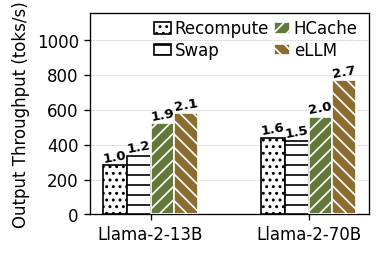

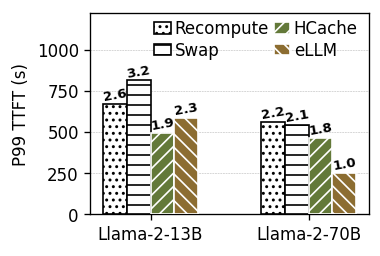

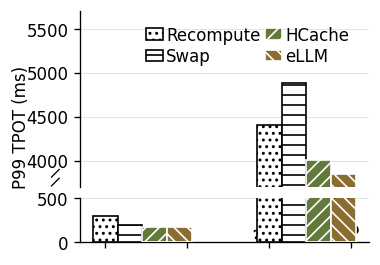

In [230]:
metrics = ['avg_output_throughput', 'avg_p99_ttft',  'avg_p99_tpot']
y_metrics = ['Output Throughput (toks/s)', 'P99 TTFT (s)', 'P99 TPOT (ms)']
model_labels = ['Llama-2-13B', 'Llama-2-70B']
for metric, y_metric in zip(metrics, y_metrics):
    plot_figure(metric, y_metric, model_names, model_labels)
    print(f"Figure for {metric} saved.")